<a href="https://colab.research.google.com/github/Janhvesh-Patil/Credit_Score_Predictor/blob/main/Credit_Risk_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!git clone https://github.com/Janhvesh-Patil/Credit_Score_Predictor

Cloning into 'Credit_Score_Predictor'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 360.27 KiB | 3.33 MiB/s, done.


In [3]:
data = pd.read_csv('/content/Credit_Score_Predictor/Corporate_Financial_Risk_Assessment_Data.csv')

In [4]:
df = pd.DataFrame(data)
df.head()

,Company_ID,Date,Industry_Sector,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Net_Income,Revenue,Operating_Income,Cash_Flow,Debt_Equity_Ratio,Return_on_Assets,Working_Capital_Ratio,Stock_Price_Close,Volatility_Index,GDP_Growth_Rate,Interest_Rate,Inflation_Rate,Financial_Risk_Label
0,C5706,2024-06-30,Finance,8.464139e+08,3.242897e+08,91702381.06,6176096.46,6.454550e+07,3.455171e+08,5.873791e+07,6.454030e+07,0.62,0.0763,14.85,478.57,20.57,7.17,7.66,3.09,0
1,C1577,2022-12-31,Technology,6.674340e+08,4.267892e+08,11734194.94,10982065.94,1.105900e+08,2.782570e+08,4.730370e+07,1.106493e+08,1.77,0.1657,1.07,577.31,35.17,6.77,6.46,1.54,0
2,C5016,2016-06-30,Energy,4.637573e+08,2.961599e+08,9983638.68,3811938.05,6.467575e+07,2.115831e+08,4.443246e+07,6.468172e+07,1.77,0.1395,2.62,463.87,33.94,2.07,9.42,6.67,0
3,C2817,2019-03-31,Manufacturing,3.592200e+08,4.980808e+07,93621021.75,49646893.27,3.085521e+07,3.130124e+07,2.504099e+06,3.077613e+07,0.16,0.0859,1.89,116.60,24.74,-4.97,1.09,4.29,0
4,C2287,2015-12-31,Manufacturing,9.776274e+08,6.220905e+08,72479345.81,35533291.66,6.517940e+07,1.593143e+07,4.460800e+06,6.524728e+07,1.75,0.0667,2.04,986.99,22.13,5.49,1.62,4.02,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company_ID             5000 non-null   object 
 1   Date                   5000 non-null   object 
 2   Industry_Sector        5000 non-null   object 
 3   Total_Assets           5000 non-null   float64
 4   Total_Liabilities      5000 non-null   float64
 5   Current_Assets         5000 non-null   float64
 6   Current_Liabilities    5000 non-null   float64
 7   Net_Income             5000 non-null   float64
 8   Revenue                5000 non-null   float64
 9   Operating_Income       5000 non-null   float64
 10  Cash_Flow              5000 non-null   float64
 11  Debt_Equity_Ratio      5000 non-null   float64
 12  Return_on_Assets       5000 non-null   float64
 13  Working_Capital_Ratio  5000 non-null   float64
 14  Stock_Price_Close      5000 non-null   float64
 15  Vola

In [6]:
df.shape

(5000, 20)

In [7]:
df.isnull().sum()

,0
Company_ID,0
Date,0
Industry_Sector,0
Total_Assets,0
Total_Liabilities,0
Current_Assets,0
Current_Liabilities,0
Net_Income,0
Revenue,0
Operating_Income,0


In [8]:
df.describe()

,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Net_Income,Revenue,Operating_Income,Cash_Flow,Debt_Equity_Ratio,Return_on_Assets,Working_Capital_Ratio,Stock_Price_Close,Volatility_Index,GDP_Growth_Rate,Interest_Rate,Inflation_Rate,Financial_Risk_Label
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.833754e+08,2.407730e+08,1.184094e+08,5.958780e+07,4.775131e+07,1.217568e+08,2.149394e+07,4.775136e+07,1.555396,0.089820,7.611308,500.773442,35.088914,2.383438,5.202010,4.508284,0.400000
std,2.935179e+08,2.052348e+08,1.086649e+08,7.111596e+07,4.533965e+07,1.092829e+08,2.282960e+07,4.533974e+07,1.252705,0.071182,39.836345,288.776315,14.644411,4.304170,2.772843,2.009676,0.489947
min,1.178336e+06,1.764299e+05,1.188305e+05,1.073868e+05,-9.939668e+05,1.030753e+05,1.023873e+04,-1.023463e+06,0.000000,-0.631800,1.000000,5.100000,10.010000,-5.000000,0.500000,1.000000,0.000000
25%,2.268248e+08,6.273467e+07,2.852557e+07,8.413930e+06,1.043151e+07,3.007102e+07,4.639155e+06,1.045156e+07,0.380000,0.039600,1.300000,245.827500,22.605000,-1.320000,2.797500,2.790000,0.000000
50%,4.872787e+08,1.889567e+08,8.349910e+07,3.055330e+07,3.507969e+07,8.686606e+07,1.394559e+07,3.516381e+07,1.200000,0.092500,1.935000,498.100000,35.060000,2.380000,5.180000,4.445000,0.000000
75%,7.398549e+08,3.824759e+08,1.817797e+08,8.495065e+07,7.475001e+07,1.927719e+08,3.017707e+07,7.474820e+07,2.750000,0.146500,3.850000,754.830000,48.010000,6.015000,7.620000,6.262500,1.000000
max,9.999760e+08,7.894634e+08,4.925274e+08,4.359167e+08,1.941520e+08,4.930028e+08,1.409000e+08,1.940968e+08,3.990000,0.199900,896.080000,999.830000,60.000000,10.000000,10.000000,8.000000,1.000000


In [9]:
print(df['Financial_Risk_Label'].value_counts())
print(df['Financial_Risk_Label'].value_counts(normalize=True) * 100)

Financial_Risk_Label
0    3000
1    2000
Name: count, dtype: int64
Financial_Risk_Label
0    60.0
1    40.0
Name: proportion, dtype: float64


In [10]:
df = df.drop(columns=["Company_ID", "Date"])


In [11]:
df

,Industry_Sector,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Net_Income,Revenue,Operating_Income,Cash_Flow,Debt_Equity_Ratio,Return_on_Assets,Working_Capital_Ratio,Stock_Price_Close,Volatility_Index,GDP_Growth_Rate,Interest_Rate,Inflation_Rate,Financial_Risk_Label
0,Finance,8.464139e+08,3.242897e+08,91702381.06,6176096.46,6.454550e+07,3.455171e+08,5.873791e+07,6.454030e+07,0.62,0.0763,14.85,478.57,20.57,7.17,7.66,3.09,0
1,Technology,6.674340e+08,4.267892e+08,11734194.94,10982065.94,1.105900e+08,2.782570e+08,4.730370e+07,1.106493e+08,1.77,0.1657,1.07,577.31,35.17,6.77,6.46,1.54,0
2,Energy,4.637573e+08,2.961599e+08,9983638.68,3811938.05,6.467575e+07,2.115831e+08,4.443246e+07,6.468172e+07,1.77,0.1395,2.62,463.87,33.94,2.07,9.42,6.67,0
3,Manufacturing,3.592200e+08,4.980808e+07,93621021.75,49646893.27,3.085521e+07,3.130124e+07,2.504099e+06,3.077613e+07,0.16,0.0859,1.89,116.60,24.74,-4.97,1.09,4.29,0
4,Manufacturing,9.776274e+08,6.220905e+08,72479345.81,35533291.66,6.517940e+07,1.593143e+07,4.460800e+06,6.524728e+07,1.75,0.0667,2.04,986.99,22.13,5.49,1.62,4.02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Energy,8.022176e+06,4.504423e+06,296120.00,241463.48,-8.163478e+05,3.867872e+06,4.254659e+05,-9.028457e+05,1.28,-0.1018,1.23,623.91,46.13,8.86,8.34,2.97,1
4996,Healthcare,1.914367e+08,6.670961e+07,8791499.21,7879294.22,3.664345e+06,7.317011e+07,2.048763e+07,3.593991e+06,0.53,0.0191,1.12,349.74,46.55,5.72,0.86,1.49,0
4997,Finance,5.462740e+08,3.909422e+08,33200248.46,7928018.38,4.756491e+07,2.011152e+07,2.815613e+06,4.754831e+07,2.52,0.0871,4.19,822.65,59.27,-2.15,2.48,7.38,1
4998,Energy,3.268740e+07,2.493520e+07,14262425.88,12916567.13,1.839967e+06,8.172466e+06,7.355220e+05,1.819333e+06,3.22,0.0563,1.10,130.52,53.16,3.72,1.79,7.15,1


In [12]:
print(df.select_dtypes(include='object').columns.tolist())

['Industry_Sector']


In [13]:
df = pd.get_dummies(df, columns=['Industry_Sector'], drop_first=True)

In [14]:
df

,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Net_Income,Revenue,Operating_Income,Cash_Flow,Debt_Equity_Ratio,Return_on_Assets,...,Volatility_Index,GDP_Growth_Rate,Interest_Rate,Inflation_Rate,Financial_Risk_Label,Industry_Sector_Finance,Industry_Sector_Healthcare,Industry_Sector_Manufacturing,Industry_Sector_Retail,Industry_Sector_Technology
0,8.464139e+08,3.242897e+08,91702381.06,6176096.46,6.454550e+07,3.455171e+08,5.873791e+07,6.454030e+07,0.62,0.0763,...,20.57,7.17,7.66,3.09,0,True,False,False,False,False
1,6.674340e+08,4.267892e+08,11734194.94,10982065.94,1.105900e+08,2.782570e+08,4.730370e+07,1.106493e+08,1.77,0.1657,...,35.17,6.77,6.46,1.54,0,False,False,False,False,True
2,4.637573e+08,2.961599e+08,9983638.68,3811938.05,6.467575e+07,2.115831e+08,4.443246e+07,6.468172e+07,1.77,0.1395,...,33.94,2.07,9.42,6.67,0,False,False,False,False,False
3,3.592200e+08,4.980808e+07,93621021.75,49646893.27,3.085521e+07,3.130124e+07,2.504099e+06,3.077613e+07,0.16,0.0859,...,24.74,-4.97,1.09,4.29,0,False,False,True,False,False
4,9.776274e+08,6.220905e+08,72479345.81,35533291.66,6.517940e+07,1.593143e+07,4.460800e+06,6.524728e+07,1.75,0.0667,...,22.13,5.49,1.62,4.02,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,8.022176e+06,4.504423e+06,296120.00,241463.48,-8.163478e+05,3.867872e+06,4.254659e+05,-9.028457e+05,1.28,-0.1018,...,46.13,8.86,8.34,2.97,1,False,False,False,False,False
4996,1.914367e+08,6.670961e+07,8791499.21,7879294.22,3.664345e+06,7.317011e+07,2.048763e+07,3.593991e+06,0.53,0.0191,...,46.55,5.72,0.86,1.49,0,False,True,False,False,False
4997,5.462740e+08,3.909422e+08,33200248.46,7928018.38,4.756491e+07,2.011152e+07,2.815613e+06,4.754831e+07,2.52,0.0871,...,59.27,-2.15,2.48,7.38,1,True,False,False,False,False
4998,3.268740e+07,2.493520e+07,14262425.88,12916567.13,1.839967e+06,8.172466e+06,7.355220e+05,1.819333e+06,3.22,0.0563,...,53.16,3.72,1.79,7.15,1,False,False,False,False,False


In [15]:
X = df.drop(columns=['Financial_Risk_Label'])
y = df['Financial_Risk_Label']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
print(df.select_dtypes(include='object').columns.tolist())

[]


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

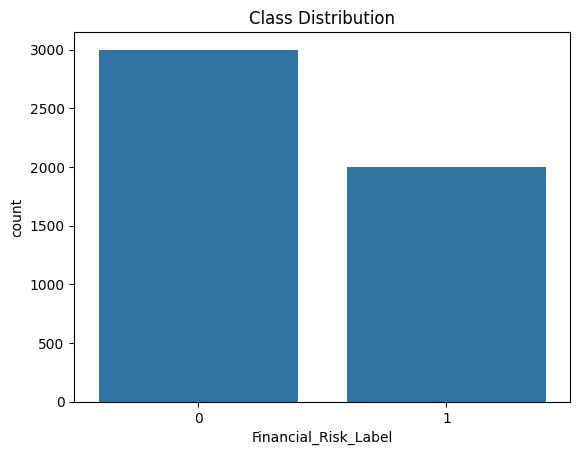

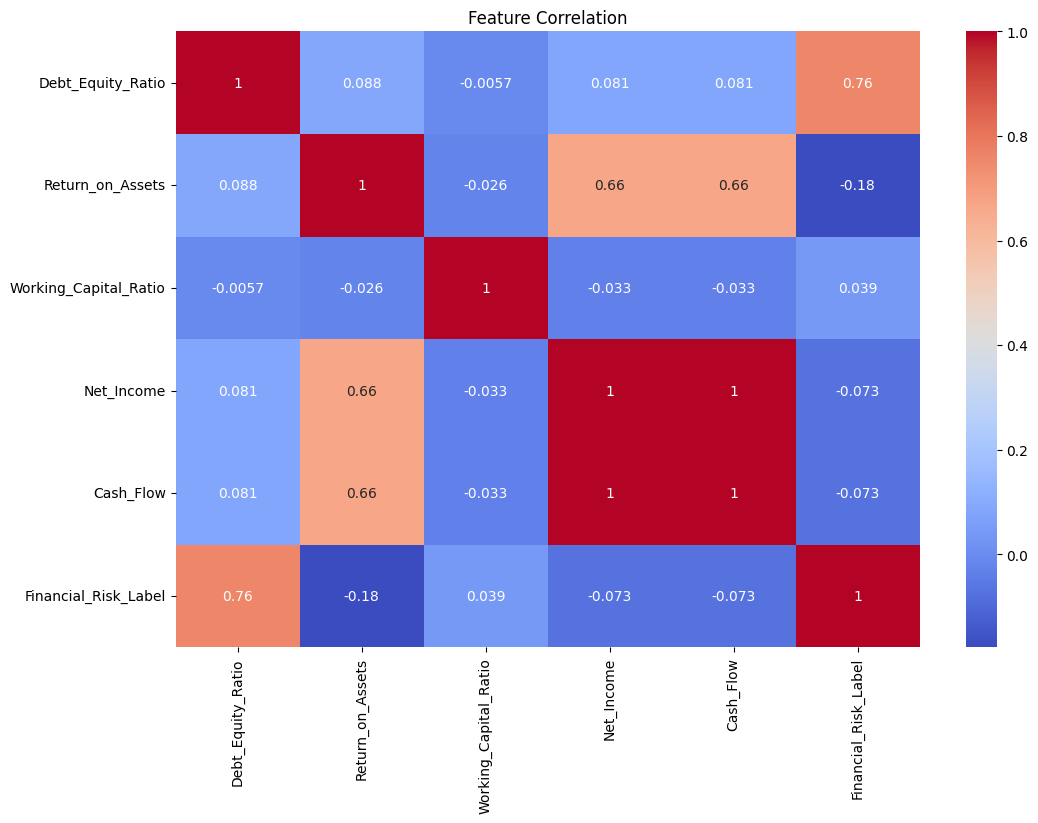

In [19]:
sns.countplot(x='Financial_Risk_Label', data=df)
plt.title('Class Distribution')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df[['Debt_Equity_Ratio', 'Return_on_Assets',
                'Working_Capital_Ratio', 'Net_Income',
                'Cash_Flow', 'Financial_Risk_Label']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [22]:
# print("X_train:", X_train_scaled.shape)
# print("X_test:", X_test_scaled.shape)
# print("y_train:", y_train.shape)
# print("y_test:", y_test.shape)

# print("Any NaN in X_train?", np.isnan(X_train_scaled).any())
# print("Any NaN in X_test?", np.isnan(X_test_scaled).any())

# print("\ny_train distribution:")
# print(y_train.value_counts(normalize=True) * 100)
# print("\ny_test distribution:")
# print(y_test.value_counts(normalize=True) * 100)


y_train distribution:
Financial_Risk_Label
0    60.0
1    40.0
Name: proportion, dtype: float64

y_test distribution:
Financial_Risk_Label
0    60.0
1    40.0
Name: proportion, dtype: float64


In [23]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight = "balanced", random_state = 42, max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

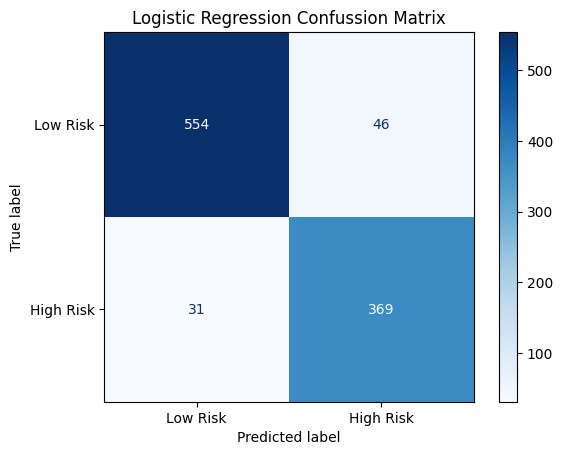

              precision    recall  f1-score   support

    Low Risk       0.95      0.92      0.94       600
   High Risk       0.89      0.92      0.91       400

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [24]:
lr_predictions = lr_model.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap = "Blues")
plt.title("Logistic Regression Confussion Matrix")
plt.show()

print(classification_report(y_test, lr_predictions, target_names = ["Low Risk", "High Risk"]))

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [26]:
rf_predictions = rf_model.predict(X_test_scaled)

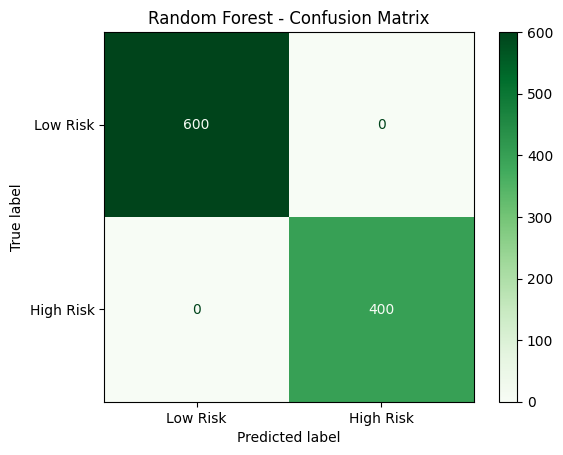

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       600
   High Risk       1.00      1.00      1.00       400

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [28]:
rf_cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

print(classification_report(y_test, rf_predictions, target_names=['Low Risk', 'High Risk']))

### Retraining the random forest model

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

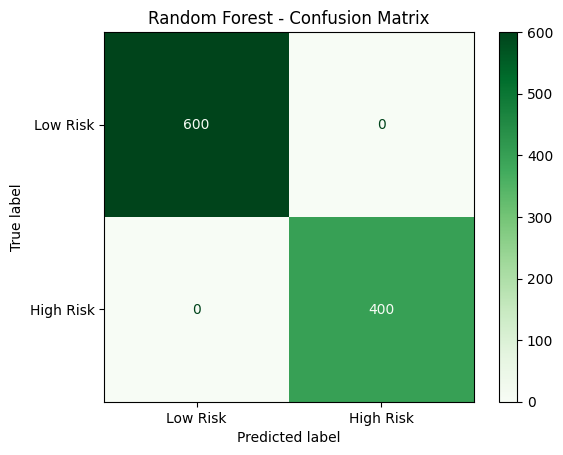

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       600
   High Risk       1.00      1.00      1.00       400

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [32]:
rf_predictions = rf_model.predict(X_test_scaled)

rf_cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

print(classification_report(y_test, rf_predictions, target_names=['Low Risk', 'High Risk']))

In [33]:
import shap

feature_names = X.columns.tolist()
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [34]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

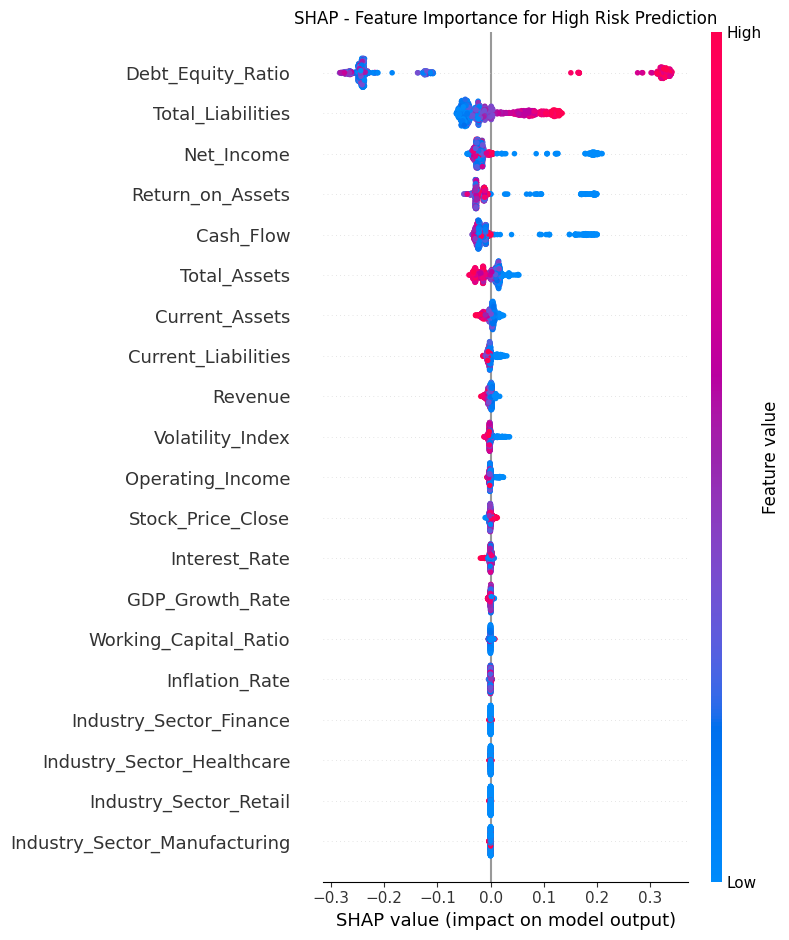

In [35]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP - Feature Importance for High Risk Prediction')
plt.tight_layout()
plt.show()

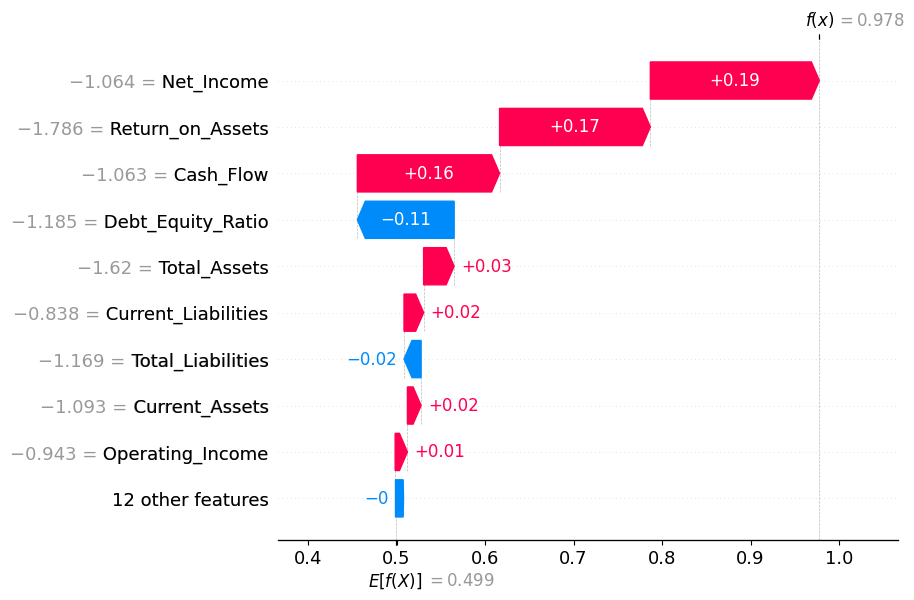

In [43]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[0],
        feature_names=feature_names
    )
)